# Model-Based Pricing Deviation — Bandung Housing Market

Pipeline terstruktur untuk prediksi harga rumah Bandung dengan analisis sinyal deviasi berbasis residual.

**Sections:**
1. Data Loading & EDA
2. Preprocessing Pipeline
3. Modeling
4. Evaluation (K-Fold CV + Test Set)
5. Residual Signal Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
pd.options.display.float_format = '{:.2e}'.format

Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading & EDA

In [2]:
# Resolve data path regardless of CWD when notebook is opened
data_path = Path('../data/results.csv')
if not data_path.exists():
    data_path = Path('data/results.csv')

# The CSV's first row is actual data (scraped), so it becomes pandas header.
# We load it as-is, then rename to semantic column names.
COLUMN_NAMES = [
    'type', 'status', 'price_raw', 'installment', 'house_name',
    'location', 'bedroom_count', 'bathroom_count', 'carport_count',
    'land_area', 'building_area'
]

df_raw = pd.read_csv(data_path, header=0)
df_raw.columns = COLUMN_NAMES

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (7610, 11)
Columns: ['type', 'status', 'price_raw', 'installment', 'house_name', 'location', 'bedroom_count', 'bathroom_count', 'carport_count', 'land_area', 'building_area']


,type,status,price_raw,installment,house_name,location,bedroom_count,bathroom_count,carport_count,land_area,building_area
0,Rumah,NaN,"Rp 4,1 Miliar",Cicilan: 15 Jutaan per bulan,Rumah Cantik @ Andir (Sudirman),"Andir, Bandung",3,2,3,202 m²,300 m²
1,Rumah,NaN,"Rp 3,3 Miliar",Cicilan: 12 Jutaan per bulan,Jual Cepat Rumah di Maleber Rajawali Bisa Untu...,"Andir, Bandung",5,2,1,350 m²,258 m²
2,Rumah,NaN,Rp 580 Juta,Cicilan: 2 Jutaan per bulan,Rumah minimalis 3 lantai di andir Bandung coco...,"Andir, Bandung",2,2,1,30 m²,80 m²


In [3]:
print('--- dtypes ---')
print(df_raw.dtypes)
print('\n--- Missing values ---')
print(df_raw.isnull().sum())
print(f'\nUnique types   : {df_raw["type"].unique()}')
print(f'Unique statuses: {df_raw["status"].unique()}')
print(f'Unique locations: {df_raw["location"].nunique()} distinct values')

--- dtypes ---
type                str
status              str
price_raw           str
installment         str
house_name          str
location            str
bedroom_count     int64
bathroom_count    int64
carport_count     int64
land_area           str
building_area       str
dtype: object

--- Missing values ---
type                 0
status            7466
price_raw            0
installment          0
house_name           0
location             0
bedroom_count        0
bathroom_count       0
carport_count        0
land_area            2
building_area        1
dtype: int64

Unique types   : <StringArray>
['Rumah']
Length: 1, dtype: str
Unique statuses: <StringArray>
[nan, 'Premier', 'Featured']
Length: 3, dtype: str
Unique locations: 27 distinct values


Price statistics:


,count,mean,std,min,25%,50%,75%,max
price_numeric,7.61e+03,4.98e+09,1.48e+10,1.20e+07,1.15e+09,2.25e+09,4.75e+09,7.35e+11


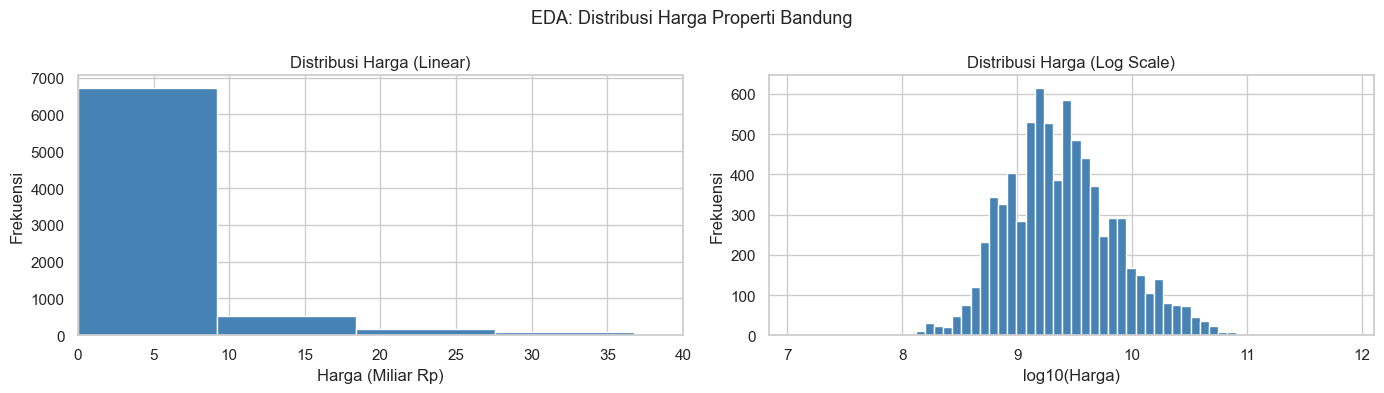

In [4]:
def parse_price(price_str):
    if not isinstance(price_str, str):
        return np.nan
    s = price_str.replace('Rp ', '').replace('.', '').replace(',', '.')
    try:
        if 'Miliar' in s:
            return float(s.replace(' Miliar', '')) * 1e9
        elif 'Juta' in s:
            return float(s.replace(' Juta', '')) * 1e6
        return float(s)
    except ValueError:
        return np.nan

df_raw['price_numeric'] = df_raw['price_raw'].apply(parse_price)

print('Price statistics:')
display(df_raw['price_numeric'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['price_numeric'].dropna() / 1e9, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Harga (Miliar Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Harga (Linear)')
axes[0].set_xlim(0, df_raw['price_numeric'].quantile(0.99) / 1e9)

axes[1].hist(np.log10(df_raw['price_numeric'].dropna()), bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log10(Harga)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Harga (Log Scale)')

plt.suptitle('EDA: Distribusi Harga Properti Bandung', fontsize=13)
plt.tight_layout()
plt.show()

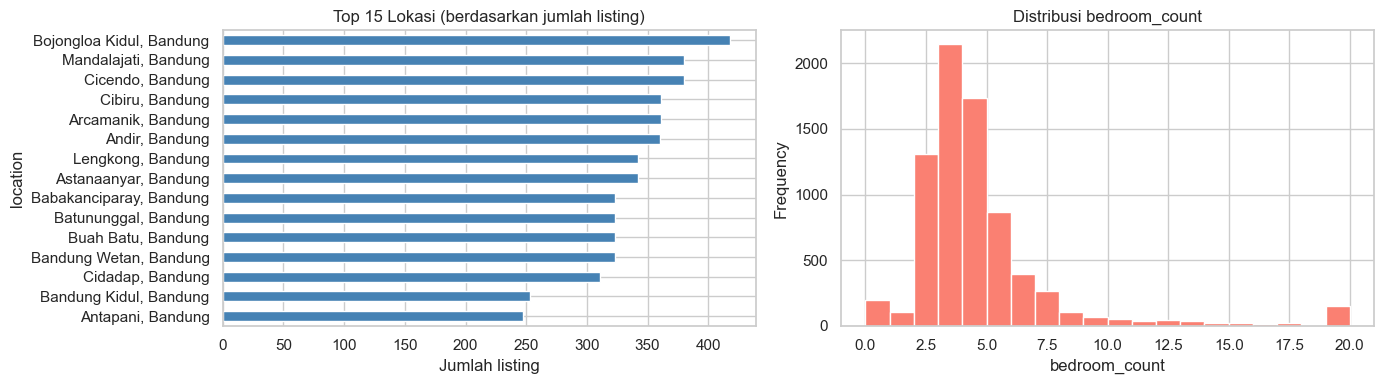


Jumlah lokasi unik: 27
Kardinalitas tinggi → gunakan Frequency Encoding, bukan One-Hot.


In [5]:
# Top locations and numeric feature distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_locs = df_raw['location'].value_counts().head(15)
top_locs.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Lokasi (berdasarkan jumlah listing)')
axes[0].set_xlabel('Jumlah listing')

for col, ax_col in [('bedroom_count', axes[1])]:
    df_raw[col].dropna().astype(float).clip(upper=20).plot(kind='hist', bins=20, ax=ax_col, color='salmon', edgecolor='white')
    ax_col.set_title(f'Distribusi {col}')
    ax_col.set_xlabel(col)

plt.tight_layout()
plt.show()

print(f'\nJumlah lokasi unik: {df_raw["location"].nunique()}')
print('Kardinalitas tinggi → gunakan Frequency Encoding, bukan One-Hot.')

## 2. Preprocessing Pipeline

In [6]:
def parse_area(area_str):
    if not isinstance(area_str, str):
        return np.nan
    try:
        return float(area_str.replace(' m\u00b2', '').replace(',', '.'))
    except ValueError:
        return np.nan

df = df_raw.copy()
df['land_area_sqm']     = df['land_area'].apply(parse_area)
df['building_area_sqm'] = df['building_area'].apply(parse_area)

# --- Bug fix: drop only rows where area is 0 or NaN, do NOT touch count columns ---
# bedroom/bathroom/carport NaN will be handled by SimpleImputer in the pipeline
before = len(df)
df = df[(df['land_area_sqm'].notna()) & (df['land_area_sqm'] > 0)]
df = df[(df['building_area_sqm'].notna()) & (df['building_area_sqm'] > 0)]
df = df.dropna(subset=['price_numeric'])
df = df.reset_index(drop=True)
after = len(df)

print(f'Rows sebelum cleaning : {before}')
print(f'Rows setelah cleaning : {after}  (drop {before - after} baris invalid area/price)')

# --- Feature engineering ---
df['building_ratio'] = df['building_area_sqm'] / df['land_area_sqm']   # masuk ke model X
df['price_per_sqm']  = df['price_numeric'] / df['land_area_sqm']        # analisis saja, bukan X

print('\nMissing values pada fitur utama setelah cleaning:')
check_cols = ['bedroom_count', 'bathroom_count', 'carport_count',
              'land_area_sqm', 'building_area_sqm', 'building_ratio']
print(df[check_cols].isnull().sum())

Rows sebelum cleaning : 7610
Rows setelah cleaning : 7606  (drop 4 baris invalid area/price)

Missing values pada fitur utama setelah cleaning:
bedroom_count        0
bathroom_count       0
carport_count        0
land_area_sqm        0
building_area_sqm    0
building_ratio       0
dtype: int64


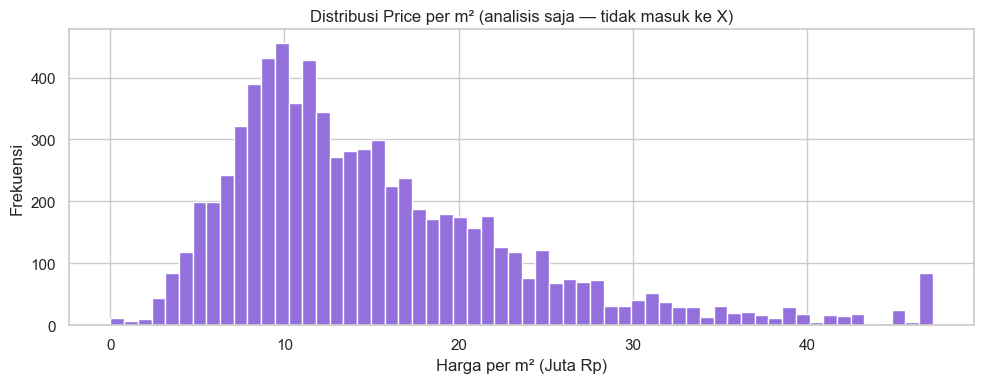

count   7.61e+03
mean    1.80e+07
std     1.64e+08
min     8.57e+03
25%     9.17e+06
50%     1.31e+07
75%     1.94e+07
max     1.11e+10
Name: price_per_sqm, dtype: float64


In [7]:
# price_per_sqm: analisis konteks, tidak masuk ke fitur model
ppsqm = df['price_per_sqm'].clip(upper=df['price_per_sqm'].quantile(0.99))
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ppsqm / 1e6, bins=60, color='mediumpurple', edgecolor='white')
ax.set_xlabel('Harga per m\u00b2 (Juta Rp)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Price per m\u00b2 (analisis saja \u2014 tidak masuk ke X)')
plt.tight_layout()
plt.show()

print(df['price_per_sqm'].describe())

In [8]:
NUMERIC_FEATURES = [
    'bedroom_count', 'bathroom_count', 'carport_count',
    'land_area_sqm', 'building_area_sqm', 'building_ratio'
]
OHE_FEATURES  = ['type', 'status']
FREQ_FEATURES = ['location']
TARGET        = 'price_numeric'

print(f'Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'OHE features     ({len(OHE_FEATURES)}): {OHE_FEATURES}')
print(f'Freq-enc features({len(FREQ_FEATURES)}): {FREQ_FEATURES}')

Numeric features (6): ['bedroom_count', 'bathroom_count', 'carport_count', 'land_area_sqm', 'building_area_sqm', 'building_ratio']
OHE features     (2): ['type', 'status']
Freq-enc features(1): ['location']


In [9]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Map each category to its relative frequency in the training set."""

    def fit(self, X, y=None):
        col = X.iloc[:, 0] if hasattr(X, 'iloc') else pd.Series(X[:, 0])
        self.freq_map_ = col.value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        col = X.iloc[:, 0] if hasattr(X, 'iloc') else pd.Series(X[:, 0])
        encoded = col.map(lambda x: self.freq_map_.get(x, 0.0))
        return encoded.values.reshape(-1, 1)

print('FrequencyEncoder defined.')

FrequencyEncoder defined.


In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',  numeric_transformer,     NUMERIC_FEATURES),
        ('ohe',  categorical_transformer, OHE_FEATURES),
        ('freq', FrequencyEncoder(),       FREQ_FEATURES)
    ],
    sparse_threshold=0  # force dense output
)

print('Preprocessing pipeline constructed.')
print('  - Numeric  : median imputation + StandardScaler')
print('  - OHE      : constant imputation ("Unknown") + OneHotEncoder(drop=first)')
print('  - Frequency: FrequencyEncoder (relative frequency per location)')

Preprocessing pipeline constructed.
  - Numeric  : median imputation + StandardScaler
  - OHE      : constant imputation ("Unknown") + OneHotEncoder(drop=first)
  - Frequency: FrequencyEncoder (relative frequency per location)


## 3. Modeling

In [11]:
X = df[NUMERIC_FEATURES + OHE_FEATURES + FREQ_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total samples : {len(df)}')
print(f'Train         : {X_train.shape}')
print(f'Test          : {X_test.shape}')

Total samples : 7606
Train         : (6084, 9)
Test          : (1522, 9)


In [12]:
alphas_ridge = np.logspace(-2, 6, 100)

models = {
    'Linear Regression': Pipeline([
        ('prep',  preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge (RidgeCV)': Pipeline([
        ('prep',  preprocessor),
        ('model', RidgeCV(alphas=alphas_ridge, cv=5))
    ]),
    'Lasso (LassoCV)': Pipeline([
        ('prep',  preprocessor),
        ('model', LassoCV(n_alphas=50, cv=5, max_iter=10000))
    ]),
    'Random Forest': Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
        ))
    ])
}

fitted_models = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    print(f'  [OK] {name} trained')

ridge_alpha = fitted_models['Ridge (RidgeCV)'].named_steps['model'].alpha_
lasso_alpha = fitted_models['Lasso (LassoCV)'].named_steps['model'].alpha_
print(f'\nRidge selected alpha : {ridge_alpha:.4f}')
print(f'Lasso selected alpha : {lasso_alpha:.4f}')

  [OK] Linear Regression trained


  [OK] Ridge (RidgeCV) trained
  [OK] Lasso (LassoCV) trained


C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.429e+20, tolerance: 9.051e+19
  model = cd_fast.enet_coordinate_descent_gram(


  [OK] Random Forest trained

Ridge selected alpha : 705.4802
Lasso selected alpha : 157636861.6709


## 4. Evaluation

In [13]:
# K-Fold CV (k=5) — preprocessor is re-fit on each fold's training split
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipeline in models.items():
    mae_scores = -cross_val_score(
        pipeline, X, y, cv=kf,
        scoring='neg_mean_absolute_error', n_jobs=1
    )
    r2_scores = cross_val_score(
        pipeline, X, y, cv=kf,
        scoring='r2', n_jobs=1
    )
    cv_results[name] = {
        'mae_mean': mae_scores.mean(),
        'mae_std':  mae_scores.std(),
        'r2_mean':  r2_scores.mean(),
        'r2_std':   r2_scores.std()
    }
    print(
        f'{name:25s} | '
        f'MAE = {mae_scores.mean():.2e} \u00b1 {mae_scores.std():.2e} | '
        f'R\u00b2 = {r2_scores.mean():.4f} \u00b1 {r2_scores.std():.4f}'
    )

Linear Regression         | MAE = 3.01e+09 ± 3.36e+08 | R² = -6.3339 ± 13.1213


Ridge (RidgeCV)           | MAE = 3.12e+09 ± 2.48e+08 | R² = -0.7665 ± 1.9432


C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.677e+20, tolerance: 1.005e+20
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Ob

C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.249e+21, tolerance: 4.487e+19
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Ob

C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.224e+21, tolerance: 1.010e+20
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Ob

C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.249e+21, tolerance: 4.487e+19
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Amanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Ob

Lasso (LassoCV)           | MAE = 3.05e+09 ± 2.41e+08 | R² = -0.3431 ± 1.1010


Random Forest             | MAE = 1.95e+09 ± 3.06e+08 | R² = 0.2631 ± 0.2433


In [14]:
# Test set evaluation
test_results = {}
for name, pipeline in fitted_models.items():
    y_pred = pipeline.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    mape   = float(np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100)
    r2     = r2_score(y_test, y_pred)
    test_results[name] = {'mae': mae, 'mape': mape, 'r2': r2, 'y_pred': y_pred}
    print(
        f'{name:25s} | '
        f'MAE = {mae:.2e} | '
        f'MAPE = {mape:6.1f}% | '
        f'R\u00b2 = {r2:.4f}'
    )

Linear Regression         | MAE = 2.98e+09 | MAPE =  149.8% | R² = 0.0659
Ridge (RidgeCV)           | MAE = 3.26e+09 | MAPE =  171.9% | R² = 0.0526
Lasso (LassoCV)           | MAE = 3.21e+09 | MAPE =  170.1% | R² = 0.0526
Random Forest             | MAE = 2.43e+09 | MAPE =  170.5% | R² = -0.0884


In [15]:
# Full comparison table
rows = []
for name in models:
    tr = test_results[name]
    cv = cv_results[name]
    rows.append({
        'Model':            name,
        'Test MAE':         f"{tr['mae'] / 1e9:.3f} B",
        'Test MAPE (%)':    f"{tr['mape']:.1f}",
        'Test R\u00b2':     f"{tr['r2']:.4f}",
        'CV MAE mean\u00b1std': f"{cv['mae_mean']:.2e} \u00b1 {cv['mae_std']:.2e}",
        'CV R\u00b2 mean\u00b1std': f"{cv['r2_mean']:.4f} \u00b1 {cv['r2_std']:.4f}"
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
pd.reset_option('display.float_format')
display(comparison_df)

,Test MAE,Test MAPE (%),Test R²,CV MAE mean±std,CV R² mean±std
Model,,,,,
Linear Regression,2.983 B,149.8,0.0659,3.01e+09 ± 3.36e+08,-6.3339 ± 13.1213
Ridge (RidgeCV),3.265 B,171.9,0.0526,3.12e+09 ± 2.48e+08,-0.7665 ± 1.9432
Lasso (LassoCV),3.214 B,170.1,0.0526,3.05e+09 ± 2.41e+08,-0.3431 ± 1.1010
Random Forest,2.429 B,170.5,-0.0884,1.95e+09 ± 3.06e+08,0.2631 ± 0.2433


## 5. Residual Signal Analysis

Residual ratio didefinisikan sebagai:

$$r = \frac{y - \hat{y}}{\hat{y}}$$

- $r > 0$ → model underestimate (harga aktual lebih tinggi dari prediksi) → **Underpriced**
- $r < 0$ → model overestimate (harga aktual lebih rendah dari prediksi) → **Overpriced**

Klasifikasi menggunakan kuantil berbasis data (bukan threshold arbitrer):
- **Underpriced** → 10% tertinggi residual ratio
- **Overpriced**  → 10% terendah residual ratio
- **Fair**        → sisanya

In [16]:
# Compute residual ratio for all models on the test set
resid_df = pd.DataFrame({'y_actual': y_test.values}, index=y_test.index)

for name, result in test_results.items():
    y_pred = result['y_pred']
    resid_df[f'y_pred_{name}']        = y_pred
    resid_df[f'resid_ratio_{name}']   = (y_test.values - y_pred) / y_pred

print('Residual ratio statistics per model:')
rr_cols = [c for c in resid_df.columns if c.startswith('resid_ratio')]
display(resid_df[rr_cols].describe().T)

Residual ratio statistics per model:


,count,mean,std,min,25%,50%,75%,max
resid_ratio_Linear Regression,1522.0,0.244174,15.662910,-54.245912,-0.539389,-0.281151,0.080824,603.971220
resid_ratio_Ridge (RidgeCV),1522.0,-0.022939,8.179482,-0.998563,-0.608206,-0.391274,-0.060122,318.020884
resid_ratio_Lasso (LassoCV),1522.0,-0.009642,8.693449,-0.998630,-0.598049,-0.373841,-0.059454,338.177919
resid_ratio_Random Forest,1522.0,0.555992,22.309912,-0.999417,-0.251604,-0.035457,0.154104,870.215790


In [17]:
def classify_deviation(series, lower_q=0.10, upper_q=0.90):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return pd.Series(
        np.where(series >= upper, 'Underpriced',
        np.where(series <= lower, 'Overpriced', 'Fair')),
        index=series.index
    )

# Use best model (Random Forest) as primary analysis signal
BEST_MODEL = 'Random Forest'
resid_df['residual_ratio']   = resid_df[f'resid_ratio_{BEST_MODEL}']
resid_df['deviation_class']  = classify_deviation(resid_df['residual_ratio'])

print(f'Deviation classification ({BEST_MODEL}):')
print(resid_df['deviation_class'].value_counts())

# Price segments based on quartile of test set
q1 = resid_df['y_actual'].quantile(0.25)
q3 = resid_df['y_actual'].quantile(0.75)
resid_df['price_segment'] = pd.cut(
    resid_df['y_actual'],
    bins=[-np.inf, q1, q3, np.inf],
    labels=['Harga Rendah', 'Harga Menengah', 'Harga Tinggi']
)

print(f'\nSegmen harga (Q1={q1/1e9:.2f}B, Q3={q3/1e9:.2f}B):')
print(resid_df['price_segment'].value_counts().sort_index())

Deviation classification (Random Forest):
deviation_class
Fair           1216
Underpriced     153
Overpriced      153
Name: count, dtype: int64

Segmen harga (Q1=1.20B, Q3=4.50B):
price_segment
Harga Rendah      385
Harga Menengah    757
Harga Tinggi      380
Name: count, dtype: int64


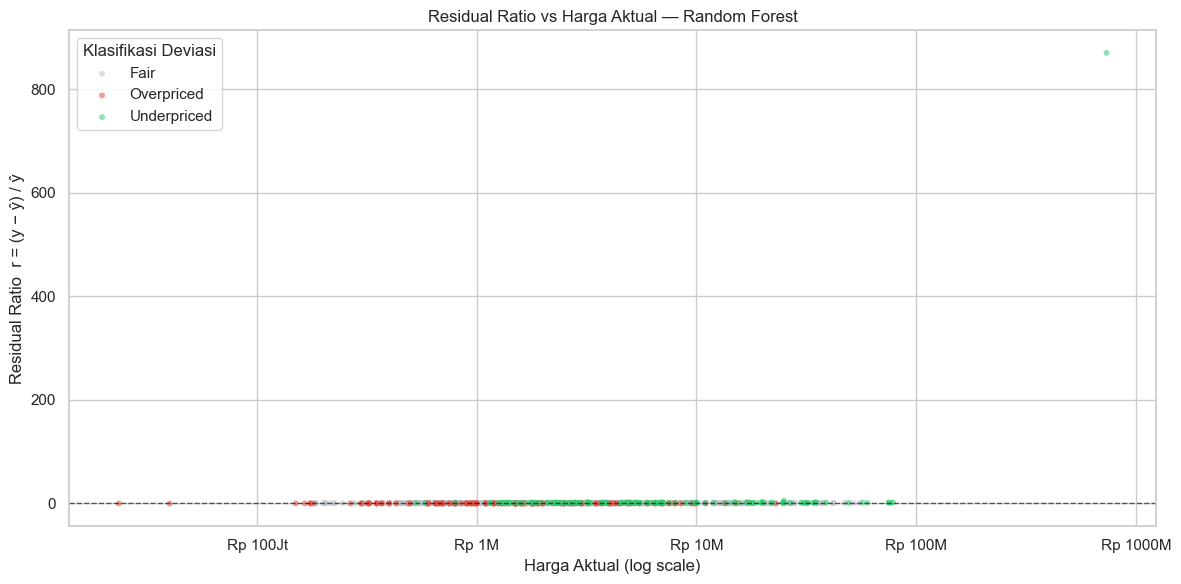

In [18]:
# Scatter plot: residual ratio vs actual price (log scale)
COLORS = {'Underpriced': '#2ecc71', 'Fair': '#bdc3c7', 'Overpriced': '#e74c3c'}

def fmt_price(x, _):
    if x >= 1e9:
        return f'Rp {x/1e9:.0f}M'
    return f'Rp {x/1e6:.0f}Jt'

fig, ax = plt.subplots(figsize=(12, 6))
for label, group in resid_df.groupby('deviation_class', observed=True):
    ax.scatter(
        group['y_actual'], group['residual_ratio'],
        c=COLORS[label], label=label, alpha=0.55, s=18, edgecolors='none'
    )

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_price))
ax.set_xlabel('Harga Aktual (log scale)')
ax.set_ylabel('Residual Ratio  r = (y \u2212 \u0177) / \u0177')
ax.set_title(f'Residual Ratio vs Harga Aktual \u2014 {BEST_MODEL}')
ax.legend(title='Klasifikasi Deviasi')
plt.tight_layout()
plt.show()

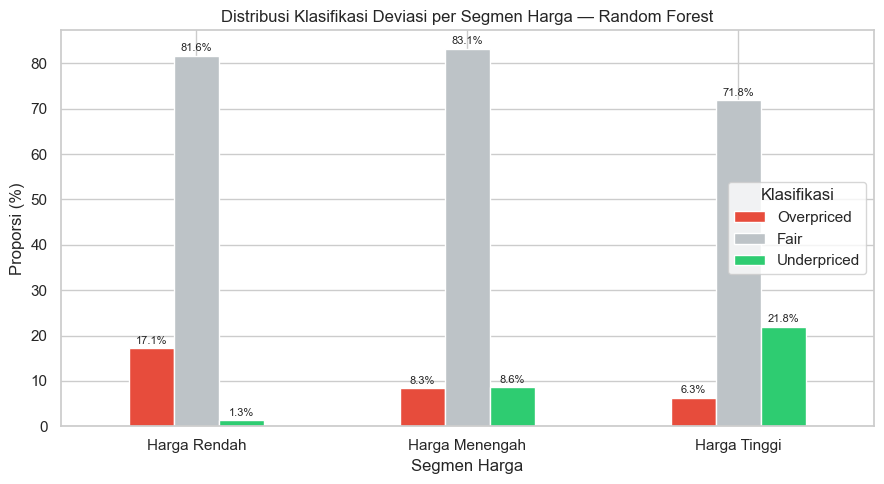

deviation_class,Overpriced,Fair,Underpriced
price_segment,,,
Harga Rendah,17.1,81.6,1.3
Harga Menengah,8.3,83.1,8.6
Harga Tinggi,6.3,71.8,21.8


In [19]:
# Bar chart: proportion of deviation class per price segment
seg_pivot = (
    resid_df
    .groupby(['price_segment', 'deviation_class'], observed=True)
    .size()
    .unstack('deviation_class', fill_value=0)
)
seg_pivot_pct = seg_pivot.div(seg_pivot.sum(axis=1), axis=0) * 100

col_order = [c for c in ['Overpriced', 'Fair', 'Underpriced'] if c in seg_pivot_pct.columns]
seg_pivot_pct = seg_pivot_pct[col_order]

fig, ax = plt.subplots(figsize=(9, 5))
seg_pivot_pct.plot(
    kind='bar', ax=ax,
    color=[COLORS[c] for c in col_order],
    edgecolor='white'
)
ax.set_xlabel('Segmen Harga')
ax.set_ylabel('Proporsi (%)')
ax.set_title(f'Distribusi Klasifikasi Deviasi per Segmen Harga \u2014 {BEST_MODEL}')
ax.legend(title='Klasifikasi')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

display(seg_pivot_pct.round(1))

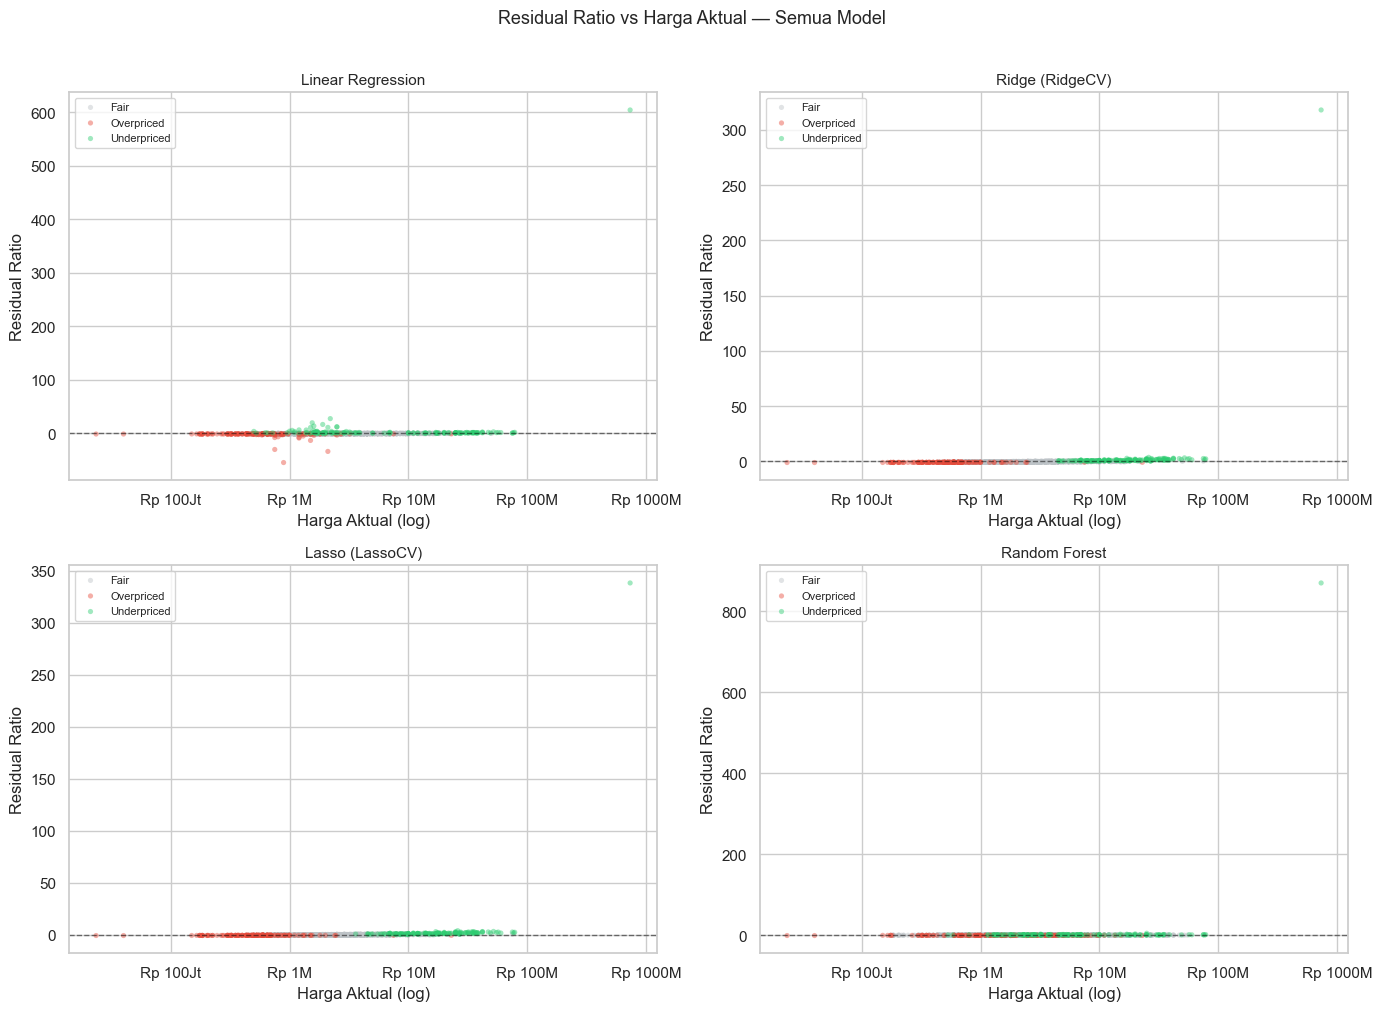

In [20]:
# Multi-model residual ratio scatter (2x2)
model_names = list(models.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flatten(), model_names):
    rr_col = f'resid_ratio_{name}'
    dev    = classify_deviation(resid_df[rr_col])
    for label, idx in dev.groupby(dev).groups.items():
        ax.scatter(
            resid_df.loc[idx, 'y_actual'],
            resid_df.loc[idx, rr_col],
            c=COLORS[label], label=label, alpha=0.45, s=14, edgecolors='none'
        )
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_price))
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Harga Aktual (log)')
    ax.set_ylabel('Residual Ratio')
    ax.legend(fontsize=8)

plt.suptitle('Residual Ratio vs Harga Aktual \u2014 Semua Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Signal consistency: % of test rows where all models agree on deviation class
classified = pd.DataFrame({
    name: classify_deviation(resid_df[f'resid_ratio_{name}'])
    for name in model_names
})
agreement_pct = classified.eq(classified.iloc[:, 0], axis=0).all(axis=1).mean() * 100
print(f'Konsistensi sinyal (semua model setuju): {agreement_pct:.1f}% dari test set')

# Final summary
print('\n' + '=' * 72)
print('MODEL COMPARISON \u2014 Full Summary')
print('=' * 72)
display(comparison_df)

Konsistensi sinyal (semua model setuju): 66.0% dari test set

MODEL COMPARISON — Full Summary


,Test MAE,Test MAPE (%),Test R²,CV MAE mean±std,CV R² mean±std
Model,,,,,
Linear Regression,2.983 B,149.8,0.0659,3.01e+09 ± 3.36e+08,-6.3339 ± 13.1213
Ridge (RidgeCV),3.265 B,171.9,0.0526,3.12e+09 ± 2.48e+08,-0.7665 ± 1.9432
Lasso (LassoCV),3.214 B,170.1,0.0526,3.05e+09 ± 2.41e+08,-0.3431 ± 1.1010
Random Forest,2.429 B,170.5,-0.0884,1.95e+09 ± 3.06e+08,0.2631 ± 0.2433
